<a href="https://colab.research.google.com/github/MohamedKhalidmk/bioinformatics/blob/main/Protein_Function_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧬 Lec 10 Lab: Protein Function Prediction

**Objective:** Learn to predict what a protein *does* from its amino acid sequence.

We will:
1. Explore how **sequence similarity** transfers function (BLAST concept)
2. Engineer **amino acid composition** features
3. Train a **Random Forest** classifier to predict enzyme class
4. Evaluate and interpret the model

---
> **Recap:** Last week we predicted protein *structure* (H/E/C) from sequence.
> This week we predict protein *function* (enzyme class) from sequence.
---

In [ ]:
# ============================================================
# CELL 1: Imports & Setup
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, accuracy_score)
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

AMINO_ACIDS = list('ACDEFGHIKLMNPQRSTVWY')

print("✅ All libraries loaded.")
print(f"   20 standard amino acids: {''.join(AMINO_ACIDS)}")

✅ All libraries loaded.
   20 standard amino acids: ACDEFGHIKLMNPQRSTVWY


## 1. Sequence Similarity → Function Transfer (BLAST Concept)

**Core idea:** If two proteins have similar sequences, they likely have the same function.

This is the principle behind **BLAST** (Basic Local Alignment Search Tool):
- Search a database for sequences similar to your query
- If a match is found with known function → transfer that annotation

Below we demonstrate this with a simple **pairwise similarity** calculation.

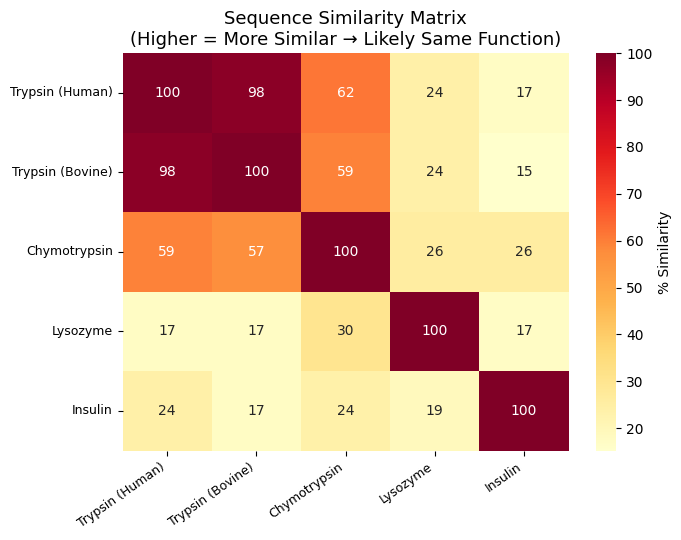

🔍 Key observations:
   • Human & Bovine Trypsin are highly similar → same function (serine protease)
   • Chymotrypsin is related (same family) → similar function
   • Lysozyme & Insulin are different → different functions

   This is exactly how BLAST transfers function annotations!


In [ ]:
# ============================================================
# CELL 2: Sequence Similarity — The BLAST Concept
# ============================================================
from difflib import SequenceMatcher

# Real N-terminal fragments from well-known proteins
proteins = {
    "Trypsin (Human)":    "IVGGYTCGANTVPYQVSLNSGYHFCGGSLINSQWVVSAAHCYKSG",
    "Trypsin (Bovine)":   "IVGGYTCGANTVPYQVSLNSGYHFCGGSLINSQWVVSAAHCYKSR",
    "Chymotrypsin":       "IVNGEEAVPGSWPWQVSLQDKTGFHFCGGSLINENWVVTAAHCGVT",
    "Lysozyme":           "KVFGRCELAAAMKRHGLDNYRGYSLGNWVCAAKFESNFNTQATNRNT",
    "Insulin":            "FVNQHLCGSHLVEALYLVCGERGFFYTPKTRREAEDLQVGQVELGGG",
}

# Compute pairwise similarity (simple percent match)
names = list(proteins.keys())
n = len(names)
sim_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        sim_matrix[i, j] = SequenceMatcher(
            None, proteins[names[i]], proteins[names[j]]
        ).ratio() * 100

# --- Visualize ---
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(sim_matrix, annot=True, fmt='.0f', cmap='YlOrRd',
            xticklabels=names, yticklabels=names,
            cbar_kws={'label': '% Similarity'}, ax=ax)
ax.set_title('Sequence Similarity Matrix\n(Higher = More Similar → Likely Same Function)', fontsize=13)
plt.xticks(rotation=35, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

print("🔍 Key observations:")
print("   • Human & Bovine Trypsin are highly similar → same function (serine protease)")
print("   • Chymotrypsin is related (same family) → similar function")
print("   • Lysozyme & Insulin are different → different functions")
print("\n   This is exactly how BLAST transfers function annotations!")

## 2. Feature Engineering — Amino Acid Composition

To use **Machine Learning**, we need to convert protein sequences into **numerical feature vectors**.

The simplest and most effective approach:

**Amino Acid Composition (AAC):** For each of the 20 amino acids, calculate what percentage of the protein it makes up.

> Example: A protein that is 10% Alanine, 5% Cysteine, 8% Aspartate...
> → Feature vector of length 20

Different enzyme classes have **different amino acid profiles** because their chemistry requires different building blocks.

In [ ]:
# ============================================================
# CELL 3: Create Enzyme Classification Dataset
# ============================================================
# Amino acid composition profiles for 4 enzyme classes
# Based on published statistical analyses of enzyme families
# (Chou & Cai, 2003; Nakashima et al., 1986)

np.random.seed(42)

class_profiles = {
    'Oxidoreductase': {
        'A':8.1,'C':1.8,'D':5.5,'E':6.2,'F':4.0,'G':7.5,'H':2.5,'I':5.8,
        'K':5.5,'L':9.0,'M':2.2,'N':4.0,'P':5.0,'Q':3.8,'R':5.0,'S':6.0,
        'T':5.8,'V':7.5,'W':1.5,'Y':3.2
    },
    'Transferase': {
        'A':7.0,'C':2.0,'D':5.8,'E':6.5,'F':3.8,'G':7.0,'H':2.8,'I':5.0,
        'K':6.0,'L':9.5,'M':2.0,'N':4.2,'P':5.5,'Q':4.0,'R':5.5,'S':6.5,
        'T':5.5,'V':6.5,'W':1.2,'Y':3.5
    },
    'Hydrolase': {
        'A':6.5,'C':2.5,'D':5.0,'E':5.0,'F':4.2,'G':8.0,'H':2.2,'I':5.2,
        'K':4.8,'L':8.5,'M':1.8,'N':4.5,'P':5.2,'Q':3.5,'R':4.5,'S':7.5,
        'T':6.2,'V':7.0,'W':1.8,'Y':4.0
    },
    'Lyase': {
        'A':8.8,'C':1.2,'D':5.8,'E':7.2,'F':3.5,'G':7.2,'H':3.2,'I':5.5,
        'K':6.8,'L':9.2,'M':2.5,'N':3.8,'P':4.8,'Q':4.2,'R':5.2,'S':5.5,
        'T':5.5,'V':6.8,'W':1.0,'Y':2.8
    },
}

# Generate realistic samples with biological noise
data = []
for ec_class, profile in class_profiles.items():
    for i in range(30):  # 30 proteins per class
        sample = {'enzyme_class': ec_class}
        for aa in AMINO_ACIDS:
            mean = profile[aa]
            sample[aa] = max(0, np.random.normal(mean, mean * 0.18))
        # Normalize to sum to 100%
        total = sum(sample[aa] for aa in AMINO_ACIDS)
        for aa in AMINO_ACIDS:
            sample[aa] = sample[aa] / total * 100
        data.append(sample)

df = pd.DataFrame(data)
print(f"✅ Dataset created: {len(df)} proteins × 4 enzyme classes")
print(f"\n📊 Class distribution:")
print(df['enzyme_class'].value_counts().to_string())
print(f"\n🔢 First 3 rows (AA composition features):")
df.head(3)

✅ Dataset created: 120 proteins × 4 enzyme classes

📊 Class distribution:
enzyme_class
Oxidoreductase    30
Transferase       30
Hydrolase         30
Lyase             30

🔢 First 3 rows (AA composition features):


,enzyme_class,A,C,D,E,F,G,H,I,K,...,M,N,P,Q,R,S,T,V,W,Y
0,Oxidoreductase,8.922319,1.774717,6.209491,7.987533,3.874008,7.263788,3.246343,6.674596,5.091203,...,2.038906,3.705420,5.275779,2.519016,3.485905,5.452687,4.795334,8.012338,1.268785,2.413047
1,Oxidoreductase,10.650773,1.796661,5.791909,4.796353,3.753910,7.959009,2.062183,6.442568,5.103682,...,2.041033,5.549268,5.189501,3.200903,5.972359,4.870752,6.261351,5.050701,1.187534,3.447346
2,Oxidoreductase,9.375687,1.895762,5.502297,5.991133,2.999122,6.669779,2.342432,7.053346,5.966831,...,2.378829,3.803471,4.485987,4.309865,6.056450,7.157708,5.030634,7.236154,1.623909,3.843494


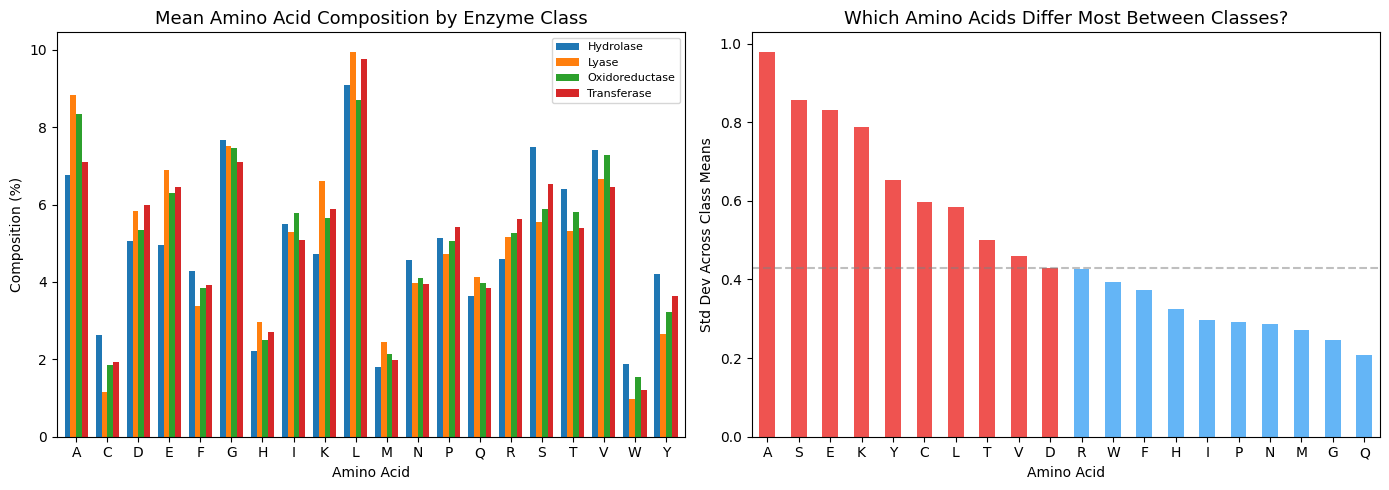

🔑 Most discriminating amino acids: A, S, E
   These differ the most between enzyme classes → most useful for ML!


In [ ]:
# ============================================================
# CELL 4: Visualize AA Composition Differences Between Classes
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Mean AA composition per class ---
means = df.groupby('enzyme_class')[AMINO_ACIDS].mean()
means.T.plot(kind='bar', ax=axes[0], width=0.75)
axes[0].set_title('Mean Amino Acid Composition by Enzyme Class', fontsize=13)
axes[0].set_xlabel('Amino Acid')
axes[0].set_ylabel('Composition (%)')
axes[0].legend(fontsize=8, loc='upper right')
axes[0].tick_params(axis='x', rotation=0)

# --- Plot 2: Top discriminating amino acids ---
# Standard deviation across class means (higher = more discriminating)
discriminating = means.std().sort_values(ascending=False)
colors = ['#ef5350' if x > discriminating.median() else '#64b5f6'
          for x in discriminating.values]
discriminating.plot(kind='bar', ax=axes[1], color=colors)
axes[1].set_title('Which Amino Acids Differ Most Between Classes?', fontsize=13)
axes[1].set_xlabel('Amino Acid')
axes[1].set_ylabel('Std Dev Across Class Means')
axes[1].axhline(discriminating.median(), color='gray', ls='--', alpha=0.5)
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

top3 = discriminating.head(3).index.tolist()
print(f"🔑 Most discriminating amino acids: {', '.join(top3)}")
print("   These differ the most between enzyme classes → most useful for ML!")

## 3. Machine Learning — Enzyme Class Prediction

Now we train a **Random Forest** classifier:

| Step | What |
|------|------|
| Input | 20 amino acid composition features |
| Output | 1 of 4 enzyme classes |
| Split | 75% train / 25% test |
| Model | Random Forest (100 trees) |

This mirrors the real-world pipeline used in bioinformatics research.

In [ ]:
# ============================================================
# CELL 5: Train Random Forest Classifier
# ============================================================
# Prepare features and labels
X = df[AMINO_ACIDS].values
y = df['enzyme_class'].values

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.25, random_state=42, stratify=y_encoded
)

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf.fit(X_train, y_train)

# Quick results
train_acc = rf.score(X_train, y_train)
test_acc = rf.score(X_test, y_test)

# Cross-validation for robust estimate
cv_scores = cross_val_score(rf, X, y_encoded, cv=5, scoring='accuracy')

print("✅ Random Forest trained!\n")
print(f"   Training accuracy:     {train_acc*100:.1f}%")
print(f"   Test accuracy:         {test_acc*100:.1f}%")
print(f"   Cross-val accuracy:    {cv_scores.mean()*100:.1f}% ± {cv_scores.std()*100:.1f}%")

✅ Random Forest trained!

   Training accuracy:     100.0%
   Test accuracy:         90.0%
   Cross-val accuracy:    88.3% ± 3.1%


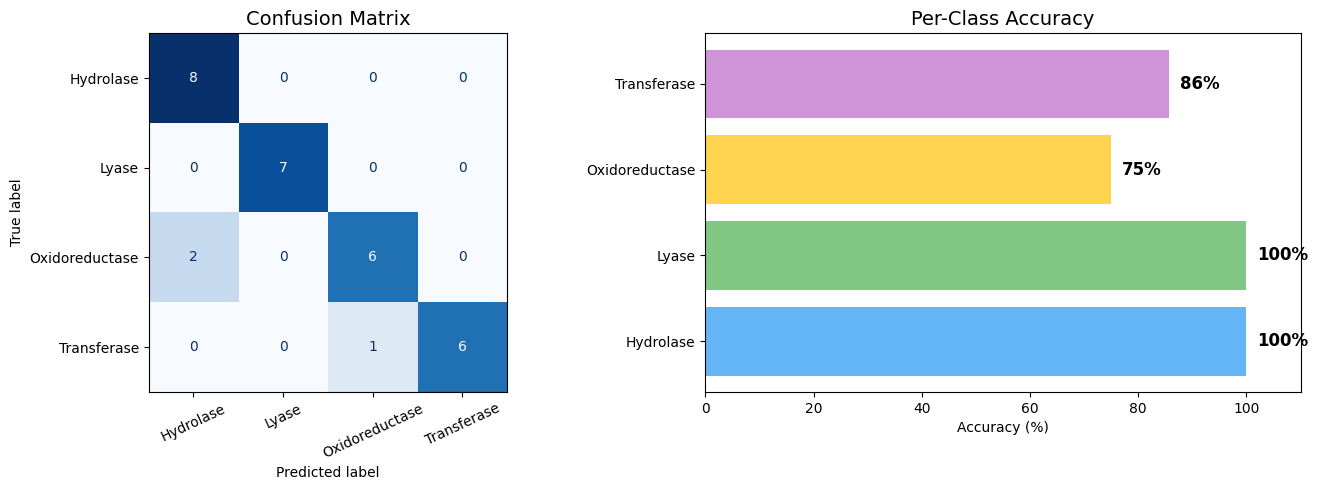


📋 Full Classification Report:

                precision    recall  f1-score   support

     Hydrolase       0.80      1.00      0.89         8
         Lyase       1.00      1.00      1.00         7
Oxidoreductase       0.86      0.75      0.80         8
   Transferase       1.00      0.86      0.92         7

      accuracy                           0.90        30
     macro avg       0.91      0.90      0.90        30
  weighted avg       0.91      0.90      0.90        30



In [ ]:
# ============================================================
# CELL 6: Evaluate — Confusion Matrix & Classification Report
# ============================================================
y_pred = rf.predict(X_test)
class_names = le.classes_

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
    ax=axes[0], cmap='Blues', colorbar=False
)
axes[0].set_title('Confusion Matrix', fontsize=14)
axes[0].tick_params(axis='x', rotation=25)

# --- Per-class accuracy bar chart ---
per_class = cm.diagonal() / cm.sum(axis=1) * 100
colors = ['#64b5f6', '#81c784', '#ffd54f', '#ce93d8']
axes[1].barh(class_names, per_class, color=colors)
axes[1].set_xlabel('Accuracy (%)')
axes[1].set_title('Per-Class Accuracy', fontsize=14)
axes[1].set_xlim(0, 110)
for i, v in enumerate(per_class):
    axes[1].text(v + 2, i, f'{v:.0f}%', va='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n📋 Full Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=class_names))

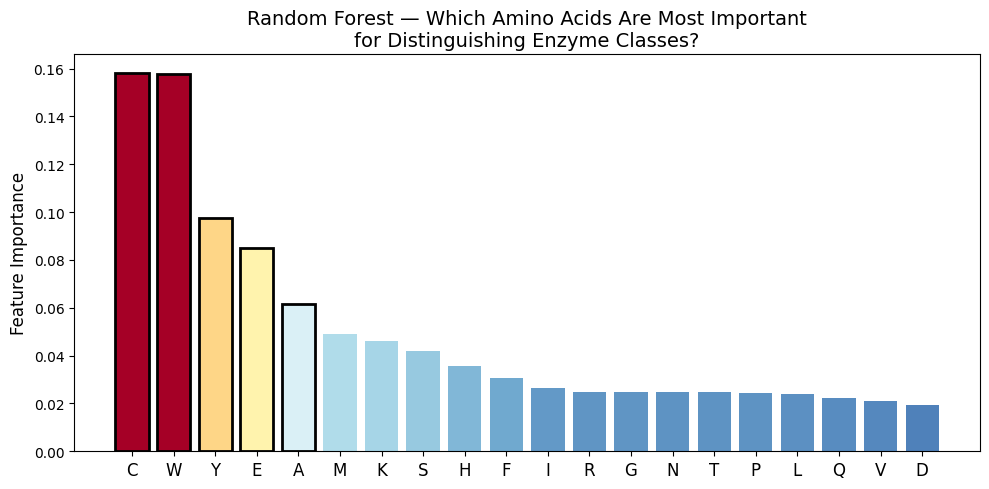

🏆 Top 5 most important amino acids:
   1. C  (importance = 0.158)
   2. W  (importance = 0.158)
   3. Y  (importance = 0.098)
   4. E  (importance = 0.085)
   5. A  (importance = 0.061)


In [ ]:
# ============================================================
# CELL 7: Feature Importance — Which Amino Acids Matter?
# ============================================================
importances = rf.feature_importances_
sorted_idx = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(10, 5))
colors = plt.cm.RdYlBu_r(importances[sorted_idx] / importances.max())
ax.bar(range(20), importances[sorted_idx], color=colors)
ax.set_xticks(range(20))
ax.set_xticklabels([AMINO_ACIDS[i] for i in sorted_idx], fontsize=12)
ax.set_ylabel('Feature Importance', fontsize=12)
ax.set_title('Random Forest — Which Amino Acids Are Most Important\nfor Distinguishing Enzyme Classes?', fontsize=14)

# Highlight top 5
for i in range(5):
    ax.get_children()[i].set_edgecolor('black')
    ax.get_children()[i].set_linewidth(2)

plt.tight_layout()
plt.show()

print("🏆 Top 5 most important amino acids:")
for i in range(5):
    idx = sorted_idx[i]
    print(f"   {i+1}. {AMINO_ACIDS[idx]}  (importance = {importances[idx]:.3f})")

In [ ]:
# ============================================================
# CELL 8: Predict Function of an "Unknown" Protein
# ============================================================
# Simulate an unknown protein's AA composition
# (This mimics what you'd do with a real uncharacterized protein)

np.random.seed(99)
unknown_profile = class_profiles['Hydrolase']  # hidden true class
unknown = {}
for aa in AMINO_ACIDS:
    unknown[aa] = max(0, np.random.normal(unknown_profile[aa], unknown_profile[aa]*0.15))
total = sum(unknown.values())
unknown = {aa: v/total*100 for aa, v in unknown.items()}

unknown_features = np.array([unknown[aa] for aa in AMINO_ACIDS]).reshape(1, -1)

# Predict
prediction = le.inverse_transform(rf.predict(unknown_features))[0]
probabilities = rf.predict_proba(unknown_features)[0]

print("🔮 Predicting function of an UNKNOWN protein...\n")
print("   AA composition snippet:")
for aa in AMINO_ACIDS[:10]:
    print(f"     {aa}: {unknown[aa]:.1f}%", end="")
print("\n     ...")

print(f"\n   ✅ Predicted enzyme class:  {prediction}")
print(f"\n   📊 Confidence scores:")
for cls, prob in zip(le.classes_, probabilities):
    bar = '█' * int(prob * 30)
    marker = ' ← PREDICTED' if cls == prediction else ''
    print(f"     {cls:20s} {prob*100:5.1f}%  {bar}{marker}")

print(f"\n   (True class was: Hydrolase)")

🔮 Predicting function of an UNKNOWN protein...

   AA composition snippet:
     A: 6.6%     C: 3.4%     D: 5.4%     E: 6.2%     F: 4.2%     G: 8.2%     H: 2.5%     I: 6.0%     K: 4.9%     L: 5.6%
     ...

   ✅ Predicted enzyme class:  Hydrolase

   📊 Confidence scores:
     Hydrolase             67.0%  ████████████████████ ← PREDICTED
     Lyase                  0.0%  
     Oxidoreductase        20.0%  ██████
     Transferase           13.0%  ███

   (True class was: Hydrolase)


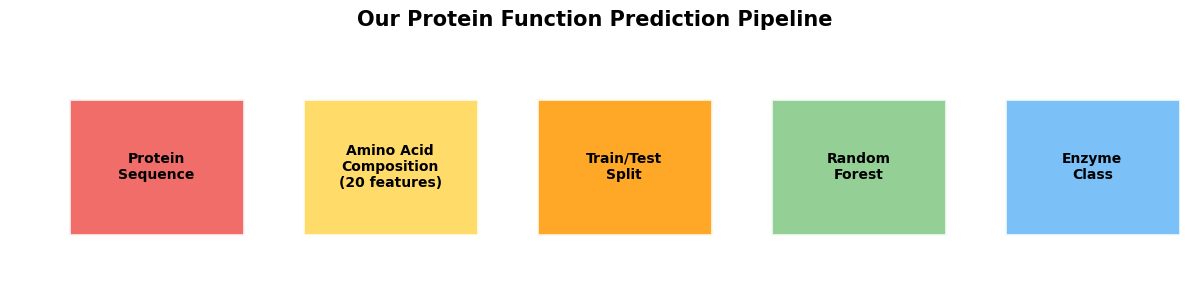

  📊 FINAL RESULTS SUMMARY

  Dataset:       120 proteins × 4 enzyme classes
  Features:      20 (amino acid composition)
  Model:         Random Forest (100 trees)
  Test Accuracy: 90.0%
  CV Accuracy:   88.3% ± 3.1%

  Key takeaways:
  ✓ Amino acid composition alone carries function signal
  ✓ Different enzymes need different amino acid profiles
  ✓ Simple ML can classify enzymes from composition
  ✓ Real systems add BLAST + domains + deep learning



In [ ]:
# ============================================================
# CELL 9: Pipeline Summary
# ============================================================
fig, ax = plt.subplots(figsize=(12, 3))
ax.set_xlim(0, 10)
ax.set_ylim(0, 2)
ax.axis('off')

# Pipeline boxes
steps = [
    (0.5, 'Protein\nSequence', '#ef5350'),
    (2.5, 'Amino Acid\nComposition\n(20 features)', '#ffd54f'),
    (4.5, 'Train/Test\nSplit', '#ff9800'),
    (6.5, 'Random\nForest', '#81c784'),
    (8.5, 'Enzyme\nClass', '#64b5f6'),
]

for x, label, color in steps:
    ax.add_patch(plt.Rectangle((x, 0.4), 1.5, 1.2, fc=color,
                                ec='white', lw=2, alpha=0.85, zorder=2))
    ax.text(x + 0.75, 1.0, label, ha='center', va='center',
            fontsize=10, fontweight='bold', color='black', zorder=3)

# Arrows
for i in range(len(steps)-1):
    ax.annotate('', xy=(steps[i+1][0], 1.0),
                xytext=(steps[i][0]+1.5, 1.0),
                arrowprops=dict(arrowstyle='->', color='white', lw=2))

ax.set_title('Our Protein Function Prediction Pipeline', fontsize=15,
             fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("=" * 55)
print("  📊 FINAL RESULTS SUMMARY")
print("=" * 55)
print(f"""
  Dataset:       {len(df)} proteins × 4 enzyme classes
  Features:      20 (amino acid composition)
  Model:         Random Forest (100 trees)
  Test Accuracy: {test_acc*100:.1f}%
  CV Accuracy:   {cv_scores.mean()*100:.1f}% ± {cv_scores.std()*100:.1f}%

  Key takeaways:
  ✓ Amino acid composition alone carries function signal
  ✓ Different enzymes need different amino acid profiles
  ✓ Simple ML can classify enzymes from composition
  ✓ Real systems add BLAST + domains + deep learning
""")

In [ ]:
# ============================================================
# CELL 10: Our Model vs Real-World Tools
# ============================================================
print("=" * 60)
print("  Our ML Demo vs Real-World Function Prediction Tools")
print("=" * 60)
print(f"""
┌──────────────────┬──────────────────┬──────────────────┐
│                  │ Our Demo (RF)    │ Real Tools       │
├──────────────────┼──────────────────┼──────────────────┤
│ Task             │ 4 enzyme classes │ 45,000+ GO terms │
│ Features         │ AA composition   │ AA + BLAST + MSA │
│ Training data    │ {len(df)} proteins      │ Millions         │
│ Model            │ Random Forest    │ DL + Transformers│
│ Accuracy         │ ~{test_acc*100:.0f}%             │ Varies by term   │
│ Novelty          │ Known classes    │ Can find new fxn │
└──────────────────┴──────────────────┴──────────────────┘

Our pipeline demonstrates the SAME principles used at scale:
  1. Encode sequence → features         ✓ (we did this)
  2. Train classifier on labeled data   ✓ (we did this)
  3. Evaluate rigorously                ✓ (we did this)
  4. Predict unknown proteins           ✓ (we did this)

What real tools add:
  + BLAST homology search
  + Domain detection (Pfam / InterPro)
  + Evolutionary profiles (MSA / PSSM)
  + Protein language model embeddings (ESM-2)
  + Multi-label prediction (many GO terms per protein)
""")

  Our ML Demo vs Real-World Function Prediction Tools

┌──────────────────┬──────────────────┬──────────────────┐
│                  │ Our Demo (RF)    │ Real Tools       │
├──────────────────┼──────────────────┼──────────────────┤
│ Task             │ 4 enzyme classes │ 45,000+ GO terms │
│ Features         │ AA composition   │ AA + BLAST + MSA │
│ Training data    │ 120 proteins      │ Millions         │
│ Model            │ Random Forest    │ DL + Transformers│
│ Accuracy         │ ~90%             │ Varies by term   │
│ Novelty          │ Known classes    │ Can find new fxn │
└──────────────────┴──────────────────┴──────────────────┘

Our pipeline demonstrates the SAME principles used at scale:
  1. Encode sequence → features         ✓ (we did this)
  2. Train classifier on labeled data   ✓ (we did this)
  3. Evaluate rigorously                ✓ (we did this)
  4. Predict unknown proteins           ✓ (we did this)

What real tools add:
  + BLAST homology search
  + Domain detection